# CRCNS AC1 — subthreshold Vm in rat auditory cortex (Wehr + Asari)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/urancon/deepSTRF/blob/develop/examples/inspect_crcns_ac1.ipynb)

This notebook is a deep dive into the **[CRCNS AC1](https://crcns.org/data-sets/ac/ac-1/about)**
dataset, which is special on two counts:

1. **It is two published datasets in one container.** The *Wehr* subset
   ([Machens, Wehr & Zador 2004](https://doi.org/10.1523/JNEUROSCI.4445-03.2004))
   and the *Asari* subset
   ([Asari & Zador 2009](https://doi.org/10.1152/jn.00577.2009)) were recorded
   in the same lab and ship together in the CRCNS release. deepSTRF exposes
   both through a single `CRCNSAC1Dataset`, switchable with the
   `experimenter=` argument.
2. **It is the only deepSTRF dataset with intracellular subthreshold
   membrane potential (Vm) for single units.** Every other auditory dataset
   ships spike counts (non-negative). Here the default target is a *signed*,
   continuous voltage trace — action potentials were pharmacologically
   blocked in the Wehr recordings, so the subthreshold synaptic input is the
   whole signal.

We'll show: the two subsets side by side, why subthreshold Vm needs different
handling than spike counts, trial-to-trial variability, how the **recording
mode** (whole-cell vs cell-attached) dictates whether the signal is
subthreshold Vm or spikes, and the difference between Wehr fragments and
Asari spliced sequences.

## Setup — Google Colab

The cell below installs deepSTRF from source on Colab; on a local
`pip install -e .` it's a no-op.

**Note on data.** CRCNS AC1 is behind a free account. With
`download=True` and `$CRCNS_USERNAME` / `$CRCNS_PASSWORD` set, the loader
fetches the three archives (~1.6 GB) from the NERSC mirror and extracts them
on first use. On a workstation with the data already unpacked, point
`CRCNS_AC1_DATA` at the directory holding the zips / extracted folders.

In [1]:
import sys
if 'google.colab' in sys.modules:
    !pip install -q git+https://github.com/urancon/deepSTRF.git
    print('deepSTRF installed from GitHub.')
else:
    print('Local environment — assuming deepSTRF is already importable.')

Local environment — assuming deepSTRF is already importable.


## Imports + paths

In [2]:
%matplotlib inline
import os
import warnings
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import torch

from deepSTRF.datasets.audio import (
    CRCNSAC1Dataset, WEHR_VALID_NEURONS, WEHR_NEURONS_SPLIT_NATURAL,
)

# Where the CRCNS AC1 dump lives. None -> platformdirs cache (+ download=True).
DATA = os.environ.get('CRCNS_AC1_DATA', None)
DOWNLOAD = False  # flip to True on first run if the data isn't local

# A few repeats per cell get gated out as artifacts; that's expected, not a bug.
warnings.simplefilter('ignore')

## 1. The two subsets at a glance

`experimenter=` selects the subset; `sites=` selects A1 vs MGB (Wehr is all
A1). We load the Wehr subset first — it's small (25 cells, sf = 4 kHz) and
loads in ~1 minute. The Asari subset comes later (it's bigger and slower).

In [3]:
wehr = CRCNSAC1Dataset(path=DATA, download=DOWNLOAD,
                       experimenter='wehr', dt_ms=5.0)
print(f'WEHR : N={wehr.N_neurons}  S={len(wehr.stims)}  F={wehr.F}')
print(f'  spectrogram: {wehr.F} log-bands, {wehr.fmin:.0f}-{wehr.fmax:.0f} Hz, dt={wehr.dt} ms')
print(f'  signal_type: {wehr.signal_type!r}  (auto-derived from recording mode)')
print(f'  coverage (cells x stims that are real): '
      f'{wehr.nrn_masks.float().mean().item()*100:.0f}% dense')
print(f'  artifact-gated repeats: {wehr._rejection_counter}')

WEHR : N=25  S=51  F=53
  spectrogram: 53 log-bands, 100-45000 Hz, dt=5.0 ms
  signal_type: 'subthresh'  (auto-derived from recording mode)
  coverage (cells x stims that are real): 22% dense
  artifact-gated repeats: {'range': 1, 'step': 0, 'xcorr': 13, 'kept': 1249}


Each neuron is one whole-cell recording session; `nrn_meta` carries the
provenance. Note the `_wehr_cell_idx` field — it indexes into the
reproducibility constants used by Rançon et al. 2024/2025.

In [4]:
for m in wehr.nrn_meta[:3]:
    print({k: m[k] for k in ('experimenter','session','site','recording_type','_wehr_cell_idx')})
print('...')
print(f'\nWEHR_VALID_NEURONS  ({len(WEHR_VALID_NEURONS)} of 25 cells used in the papers):')
print(' ', WEHR_VALID_NEURONS)

{'experimenter': 'wehr', 'session': '20020508-mw-003', 'site': 'A1', 'recording_type': 'whole-cell', '_wehr_cell_idx': 0}
{'experimenter': 'wehr', 'session': '20020530-mw-001', 'site': 'A1', 'recording_type': 'whole-cell', '_wehr_cell_idx': 1}
{'experimenter': 'wehr', 'session': '20020602-mw-001', 'site': 'A1', 'recording_type': 'whole-cell', '_wehr_cell_idx': 2}
...

WEHR_VALID_NEURONS  (21 of 25 cells used in the papers):
  (0, 3, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24)


## 2. Subthreshold Vm is *signed* — unlike spike counts

Whole-cell recordings give the membrane potential after MedGauss drift
removal (median + gaussian baseline subtracted). Because the baseline is
removed, the trace oscillates **around zero** — roughly half the values are
negative. Any loss / metric you apply must tolerate that: use MSE, not
Poisson (which assumes non-negative rates).

For all the single-cell demos below we pick the `(cell, stim)` pair with the
most repeated presentations — the clearest window onto trial-to-trial
structure.

cell 9: 10 stims; demo stim 5 (knudsens frog) with R=25 trials


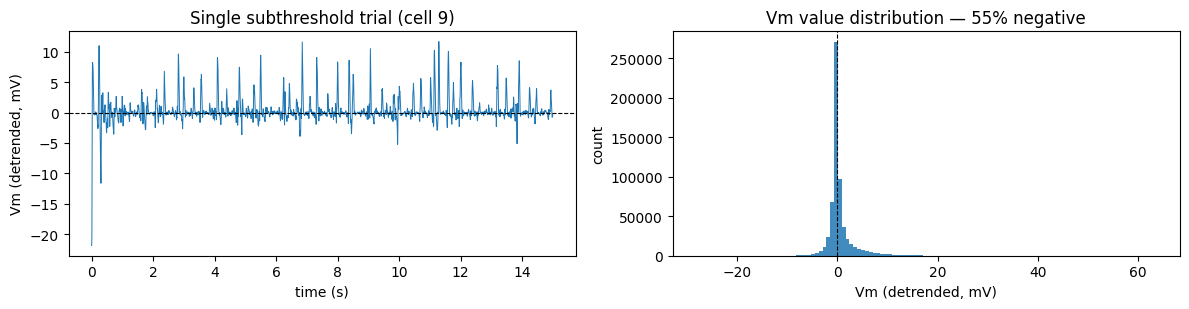

In [5]:
# Pick the (cell, stim) pair with the most repeats — the best trial-to-trial
# variability demo. Also note how many stims that cell heard overall.
best = max(
    ((wehr.responses[s][n].shape[0], n, s)
     for n in range(wehr.N_neurons) for s in range(len(wehr.stims))
     if wehr.nrn_masks[s, n]),
)
_, cell, demo_stim = best
stims_for_cell = [s for s in range(len(wehr.stims)) if wehr.nrn_masks[s, cell]]

resp = wehr.responses[demo_stim][cell].numpy()      # (R, T)
R, T = resp.shape
t_ax = np.arange(T) * wehr.dt / 1000.0
print(f'cell {cell}: {len(stims_for_cell)} stims; demo stim {demo_stim} '
      f"({wehr.stim_meta[demo_stim]['description']}) with R={R} trials")

# pool all this cell's Vm values to show the sign distribution
allvals = np.concatenate([wehr.responses[s][cell].numpy().ravel() for s in stims_for_cell])

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))
ax[0].plot(t_ax, resp[0], lw=0.7)
ax[0].axhline(0, color='k', lw=0.8, ls='--')
ax[0].set(title=f'Single subthreshold trial (cell {cell})',
          xlabel='time (s)', ylabel='Vm (detrended, mV)')
ax[1].hist(allvals, bins=120, alpha=0.85)
ax[1].axvline(0, color='k', lw=0.8, ls='--')
ax[1].set(title=f'Vm value distribution — {(allvals<0).mean()*100:.0f}% negative',
          xlabel='Vm (detrended, mV)', ylabel='count')
fig.tight_layout(); plt.show()

## 3. Trial-to-trial variability

Whole-cell Vm is remarkably reliable across repeats — the stimulus-locked
deflections line up trial after trial, while a smaller fraction of the
variance is trial-specific. Overlaying all `R` trials (thin) against their
mean / PSTH (thick) gives a quick visual read on the SNR of a cell. This is
exactly what the Sahani-Linden SNR (`compute_neuron_quality()`) quantifies.

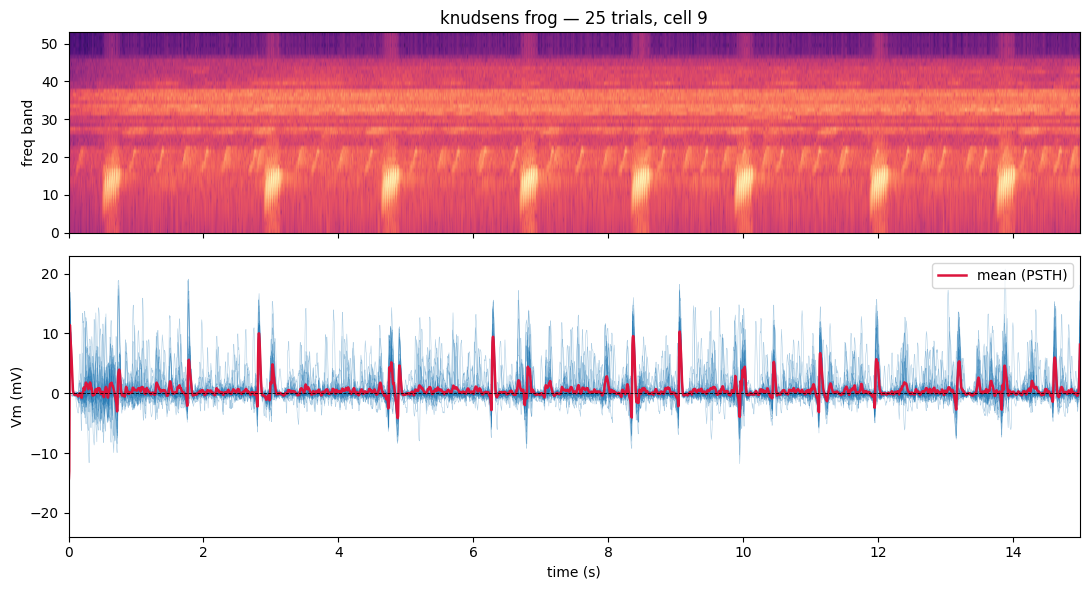

In [6]:
spec = wehr.stims[demo_stim][0].numpy()       # (F, T)
mean_trace = resp.mean(0)

fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                       gridspec_kw={'height_ratios': [1, 1.4]})
ax[0].imshow(spec, aspect='auto', origin='lower', cmap='magma',
             extent=[0, t_ax[-1], 0, wehr.F])
ax[0].set(ylabel='freq band',
          title=f"{wehr.stim_meta[demo_stim]['description']} — {R} trials, cell {cell}")
for r in range(R):
    ax[1].plot(t_ax, resp[r], lw=0.4, color='C0', alpha=0.35)
ax[1].plot(t_ax, mean_trace, lw=1.8, color='crimson', label='mean (PSTH)')
ax[1].axhline(0, color='k', lw=0.6, ls='--')
ax[1].set(xlabel='time (s)', ylabel='Vm (mV)')
ax[1].legend(loc='upper right')
fig.tight_layout(); plt.show()

## 4. The recording mode determines the signal (subthreshold vs spikes)

deepSTRF does **not** let you pick the signal type by hand — it's dictated by
how each cell was recorded, because the recording mode decides what signal
physically exists:

| recording mode | subset | signal (`nrn_meta['signal_type']`) | sign | pair with |
|----------------|--------|-----------------------------------|------|-----------|
| **whole-cell** | Wehr, Asari A1 | `'subthresh'` — MedGauss-detrended Vm | signed | `mse_loss` |
| **cell-attached** | Asari MGB | `'spikes'` — Hann-smoothed spike-rate | ≥ 0 | `poisson_loss` |

Cell-attached recordings (MGB) have **no intracellular Vm** at all — the
trace is dominated by extracellular action potentials. Whole-cell recordings
(Wehr, Asari A1) carry subthreshold Vm and **no spikes** (blocked in Wehr,
not analysed in Asari A1). So the right target is fixed by the data, and the
loader sets it automatically.

To see real spikes we load the **Asari MGB** cohort (cell-attached). This is
a few-minute load.

ASARI MGB : N=14  signal_type='spikes'  rec={'cell-attached'}
  MGB cell 1: R=23 trials, mean rate ~85 a.u./s


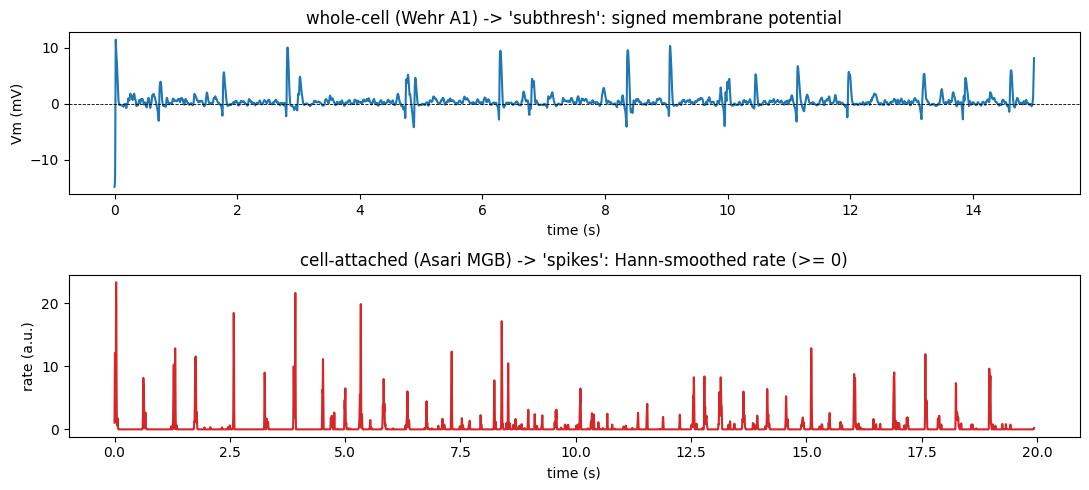

subthresh min = -14.78 mV   |   MGB spikes min = 0.00 (a.u.)


In [7]:
mgb = CRCNSAC1Dataset(path=DATA, download=DOWNLOAD,
                      experimenter='asari', sites='MGB', dt_ms=5.0)
print(f'ASARI MGB : N={mgb.N_neurons}  signal_type={mgb.signal_type!r}  '
      f"rec={set(m['recording_type'] for m in mgb.nrn_meta)}")

# A spike-rate PSTH from one MGB cell, next to the Wehr subthreshold Vm.
m_cell = int(mgb.nrn_masks.sum(0).argmax())
m_stims = [s for s in range(len(mgb.stims)) if mgb.nrn_masks[s, m_cell]]
m_stim = max(m_stims, key=lambda s: mgb.responses[s][m_cell].shape[0])
m_resp = mgb.responses[m_stim][m_cell].numpy()
m_psth = m_resp.mean(0)
m_t = np.arange(m_psth.size) * mgb.dt / 1000.0
# mean evoked rate sanity check (Asari 2009 report ~11 Hz evoked in MGB)
mean_rate_hz = m_psth.mean() / (mgb.dt / 1000.0)
print(f'  MGB cell {m_cell}: R={m_resp.shape[0]} trials, mean rate ~{mean_rate_hz:.0f} a.u./s')

fig, ax = plt.subplots(2, 1, figsize=(11, 5), sharex=False)
ax[0].plot(t_ax[:len(mean_trace)], mean_trace, color='C0')
ax[0].axhline(0, color='k', lw=0.6, ls='--')
ax[0].set(ylabel='Vm (mV)', xlabel='time (s)',
          title="whole-cell (Wehr A1) -> 'subthresh': signed membrane potential")
ax[1].plot(m_t, m_psth, color='C3')
ax[1].set(ylabel='rate (a.u.)', xlabel='time (s)',
          title="cell-attached (Asari MGB) -> 'spikes': Hann-smoothed rate (>= 0)")
fig.tight_layout(); plt.show()
print(f'subthresh min = {mean_trace.min():+.2f} mV   |   MGB spikes min = {m_psth.min():.2f} (a.u.)')

## 5. Wehr fragments vs Asari spliced sequences

The two subsets differ in their **stimulus design**, which the loader
surfaces in `stim_meta`:

- **Wehr** plays single 15 s natural-sound *fragments* (`humpback whale`,
  `jaguar mating call`, ...) at sf = 4 kHz.
- **Asari** plays *sequences* that splice 5 short segments together (e.g.
  `'Sequence 1: 2 1 3 1 4'`) at sf = 10 kHz, to probe long-range context
  dependence. The loader resolves each sequence to the exact segment files
  and records them in `stim_meta['segment_files']`.

Here we load the Asari **A1** cohort so both panels show subthreshold Vm —
isolating the *stimulus* difference from the signal-type difference of §4.
Like the MGB load, this takes a few minutes (39 whole-cell recordings at
10 kHz).

In [8]:
asari = CRCNSAC1Dataset(path=DATA, download=DOWNLOAD,
                        experimenter='asari', sites='A1', dt_ms=5.0)
print(f'ASARI A1 : N={asari.N_neurons}  S={len(asari.stims)}  F={asari.F}')
print(f'  artifact-gated repeats: {asari._rejection_counter}')

a_cell = int(asari.nrn_masks.sum(0).argmax())
a_stims = [s for s in range(len(asari.stims)) if asari.nrn_masks[s, a_cell]]
a_stim = max(a_stims, key=lambda s: asari.responses[s][a_cell].shape[0])
sm = asari.stim_meta[a_stim]
print(f"  demo sequence: {sm['sequence']}")
print(f"  spliced from: {sm['segment_files']}")

ASARI A1 : N=39  S=67  F=53
  artifact-gated repeats: {'range': 0, 'step': 0, 'xcorr': 18, 'kept': 1859}
  demo sequence: Sequence 1: 2 1 3 1 4
  spliced from: ('class4/6.mat', 'class4/5.mat', 'class4/7.mat', 'class4/5.mat', 'class4/8.mat')


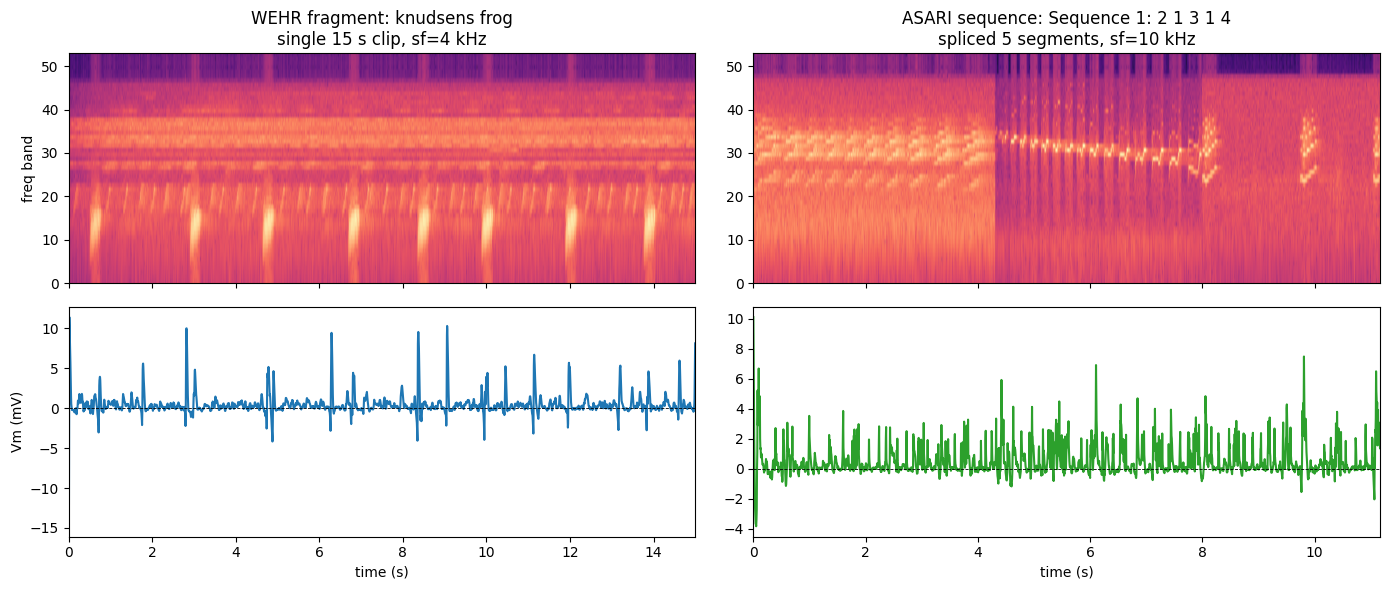

In [9]:
a_spec = asari.stims[a_stim][0].numpy()
a_resp = asari.responses[a_stim][a_cell].numpy().mean(0)
a_t = np.arange(a_spec.shape[1]) * asari.dt / 1000.0

fig, ax = plt.subplots(2, 2, figsize=(14, 6), sharex='col')
ax[0,0].imshow(spec, aspect='auto', origin='lower', cmap='magma',
               extent=[0, t_ax[-1], 0, wehr.F])
ax[0,0].set(ylabel='freq band',
            title=f"WEHR fragment: {wehr.stim_meta[demo_stim]['description']}\n"
                  f'single 15 s clip, sf=4 kHz')
ax[1,0].plot(t_ax, mean_trace, color='C0'); ax[1,0].axhline(0, color='k', lw=0.6, ls='--')
ax[1,0].set(xlabel='time (s)', ylabel='Vm (mV)')
ax[0,1].imshow(a_spec, aspect='auto', origin='lower', cmap='magma',
               extent=[0, a_t[-1], 0, asari.F])
ax[0,1].set(title=f"ASARI sequence: {sm['sequence']}\n"
                  f"spliced {len(sm['segments'])} segments, sf=10 kHz")
ax[1,1].plot(a_t, a_resp, color='C2'); ax[1,1].axhline(0, color='k', lw=0.6, ls='--')
ax[1,1].set(xlabel='time (s)')
fig.tight_layout(); plt.show()

## 6. Under the hood — MedGauss detrend + artifact gating

Intracellular recordings drift (slow baseline wander) and occasionally jump
(electrode movement, dropouts). The loader handles both before you ever see
the data:

1. **MedGauss detrend** — subtract a median-then-gaussian low-pass baseline
   (100 ms median, 10 ms σ), removing drift while preserving fast Vm dynamics.
2. **Per-repeat gating** (`RepeatGating`) — drop trials that clip the
   amplifier range, sit on a sustained baseline step (movement / dropout the
   baseline can't track), or disagree with their peers (low cross-trial
   correlation).

The raw traces aren't on the public dataset (only the cleaned responses are),
but we can call the native ingest helpers to visualise one raw trial, its
baseline, and the detrended result.

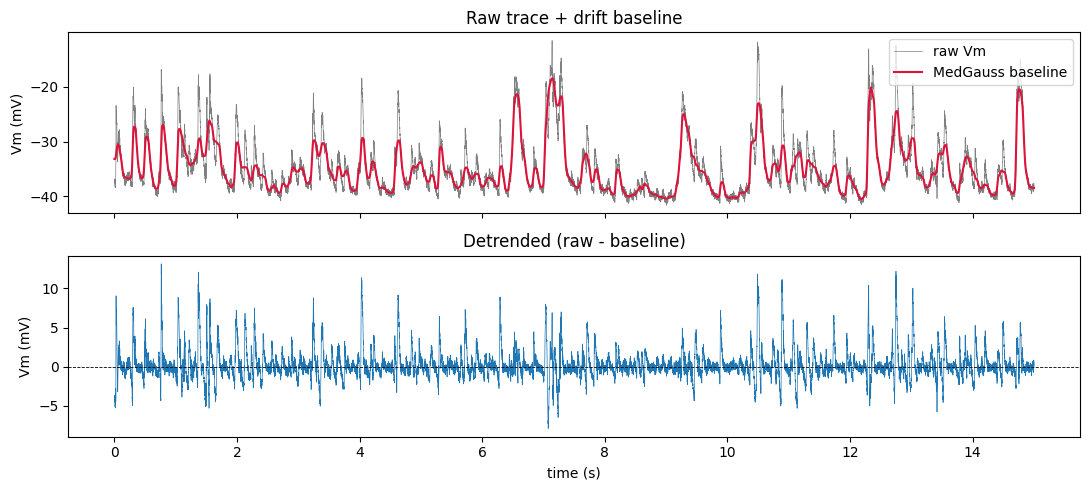

Repeats kept vs rejected, by reason:
  WEHR    : {'range': 1, 'step': 0, 'xcorr': 13, 'kept': 1249}
  ASARI A1: {'range': 0, 'step': 0, 'xcorr': 18, 'kept': 1859}


In [10]:
from deepSTRF.datasets.audio._crcns_ac1_native import (
    ensure_extracted, iterate_wehr_cells, medgauss_detrend,
)

wehr_dir, _, _ = ensure_extracted(wehr.path)
raw_cell = next(iterate_wehr_cells(wehr_dir))   # first session
raw_stim = raw_cell.stims[0]
raw = raw_stim.raw_repeats[0]                    # one raw Vm trial (mV, sf=4kHz)
sf = raw_stim.sf_resp
detr = medgauss_detrend(raw, sf)
baseline = raw - detr
tt = np.arange(raw.size) / sf

fig, ax = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
ax[0].plot(tt, raw, lw=0.5, color='gray', label='raw Vm')
ax[0].plot(tt, baseline, lw=1.5, color='crimson', label='MedGauss baseline')
ax[0].legend(loc='upper right'); ax[0].set(ylabel='Vm (mV)', title='Raw trace + drift baseline')
ax[1].plot(tt, detr, lw=0.5, color='C0'); ax[1].axhline(0, color='k', lw=0.6, ls='--')
ax[1].set(xlabel='time (s)', ylabel='Vm (mV)', title='Detrended (raw - baseline)')
fig.tight_layout(); plt.show()

print('Repeats kept vs rejected, by reason:')
print('  WEHR    :', wehr._rejection_counter)
print('  ASARI A1:', asari._rejection_counter)

The median window (`detrend_med_ms`, default 100 ms) is a constructor
argument. It barely matters here: because the response is dominated by fast
PSP transients (much shorter than 100 ms), the detrended residual is almost
identical from 100 ms up to 1 s. Longer windows preserve marginally more slow
Vm dynamics; shorter windows detrend more aggressively.

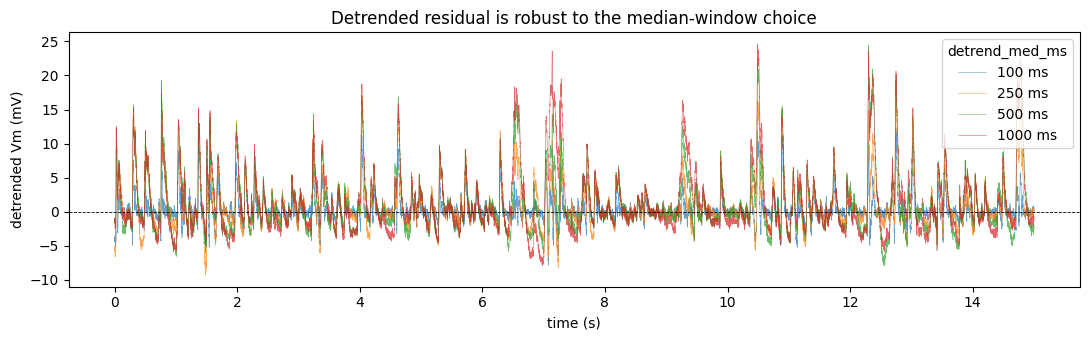

In [11]:
fig, ax = plt.subplots(figsize=(11, 3.5))
for med in (100, 250, 500, 1000):
    ax.plot(tt, medgauss_detrend(raw, sf, med_ms=med), lw=0.4, alpha=0.7, label=f'{med} ms')
ax.axhline(0, color='k', lw=0.6, ls='--')
ax.set(xlabel='time (s)', ylabel='detrended Vm (mV)',
       title='Detrended residual is robust to the median-window choice')
ax.legend(title='detrend_med_ms'); fig.tight_layout(); plt.show()

## 7. Filtering + reproducibility constants

The standard deepSTRF filter API works on both subsets. Because they share a
class, you can also load both at once and split by `experimenter` /  `site`.
For the Rançon et al. STRF baseline, reduce to the published cell list and
per-neuron split with the two exported constants.

In [12]:
# Load BOTH subsets in one object, then split by experimenter.
# (Asari MGB is included here; this is the full-dataset load.)
# both = CRCNSAC1Dataset(path=DATA, download=DOWNLOAD, dt_ms=5.0)  # ~12 min
# print('combined N =', both.N_neurons)

# Reproducibility: keep only the 21 published Wehr cells.
keep = wehr.select_pop_by_nrn_predicate(
    lambda n: n['_wehr_cell_idx'] in WEHR_VALID_NEURONS
)
print(f'kept {len(keep)} of {wehr.N_neurons} Wehr cells (the published cohort)')

# Their (train, val, test) stim-count splits used in the papers:
for n in keep[:5]:
    idx = wehr.nrn_meta[n]['_wehr_cell_idx']
    print(f"  cell_idx {idx:2d}: split (train,val,test) = {WEHR_NEURONS_SPLIT_NATURAL[idx]}")

kept 21 of 25 Wehr cells (the published cohort)
  cell_idx  0: split (train,val,test) = (7, 2, 2)
  cell_idx  3: split (train,val,test) = (7, 1, 1)
  cell_idx  5: split (train,val,test) = (6, 1, 1)
  cell_idx  6: split (train,val,test) = (3, 1, 1)
  cell_idx  7: split (train,val,test) = (1, 1, 1)


## What's next

- **STRF / LN baselines.** The `Fitter` (see `docs/_source/md/fitter.md`)
  ports unchanged. For the whole-cell subthreshold cohorts pair it with
  `mse_loss`; for the cell-attached MGB spikes (`sites='MGB'`) pair with
  `poisson_loss`. Don't mix the two cohorts under one model — they're in
  different units (the loader warns you if you load both).
- **Per-cell quality.** Call `ds.compute_neuron_quality()` to write
  Sahani-Linden `snr` + Hsu/Spearman-Brown `ccmax` into `nrn_meta`, then
  filter on them (`select_pop_by_nrn_predicate(lambda n: n['snr'] > 0.5)`).
- **Wehr-2024 spectrogram layout.** Pass `fmax=25600.0` to recover the
  49-band setting (vs the 53-band Asari-2025 default used here).
- **Tune the detrend.** `detrend_med_ms` (default 100 ms) sets the MedGauss
  median window; raise it to preserve more slow Vm dynamics, lower it to
  detrend more aggressively. The choice is robust — residuals barely change
  between 100 and 1000 ms because fast PSP transients dominate the response.
- **Reproduce the paper numbers.** Linear STRF on the published Wehr cohort
  lands around `cc_norm = 0.21` (population mean, Rançon et al. 2025 Table 1).